# Postprocessing after training

Import custom functions and define paths to datadirectories.

In [1]:
%load_ext autoreload
%autoreload 2

In [18]:
import numpy as np
import sys
from pathlib import Path
scripts_dir = Path.cwd().parents[1]
if str(scripts_dir) not in sys.path:
    sys.path.insert(0, str(scripts_dir))
from gan_pipeline.core import custom_plots as custom_plots
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from postprocessing import PostProcessing
custom_plots.apply_custom_plotting_flavor()

gan_data_dir = Path(r"C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\outputs\post_editing\RUN_10000_of_20000_samples_10_epochs_bs_64_val_size_010_no_disc_penalty\realizations\*.npy")
real_data_dir = Path(r"C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\datasets\training\setting_1_nexus_1000_samples_ntg_0.67_chdepth_6_isbx_100\samples\facies\*.npy")
output_dir = Path(r"C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_editing_plots")

## Inspect Loss history

Found 1 history files: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\outputs\post_editing\RUN_10000_of_20000_samples_10_epochs_bs_64_val_size_010_no_disc_penalty


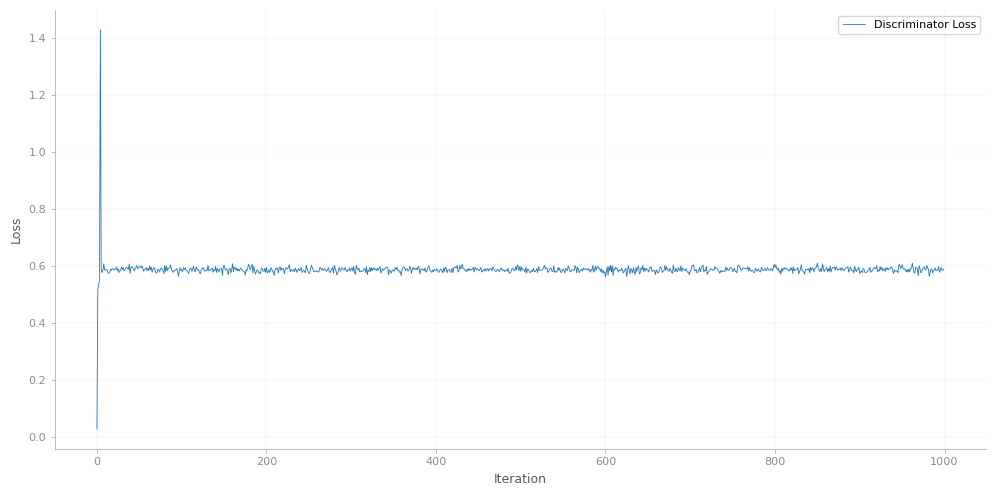

In [19]:
history_dir = gan_data_dir.parent.parent

try:
    history_files = list(history_dir.glob("*.csv"))
    print(f"Found {len(history_files)} history files: {history_dir}")
except Exception as e:
    print(f"Error accessing history directory: {history_dir}")
    print(e)

Loss = pd.read_csv(history_files[0])
step = np.arange(len(Loss))

plt.figure(figsize=(10, 5))
plt.grid()
plt.plot(step, Loss['loss'], label='Discriminator Loss') 
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

## Initialize postprocessing class

In [3]:
Postproc = PostProcessing(output_dir=output_dir,real_path=real_data_dir,gan_path=gan_data_dir, save_plots=True, num_samples=1000)

In [4]:
Postproc.plot_entropy()


--- Generating Entropy Matrices (100 Realizations) ---
Saved XY entropy plot to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_editing_plots\entropy_matrix_XY_realizations_100_samples.png
Saved ZX entropy plot to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_editing_plots\entropy_matrix_ZX_realizations_100_samples.png
Saved ZY entropy plot to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_editing_plots\entropy_matrix_ZY_realizations_100_samples.png
